In [40]:
import sys

print(sys.executable)
print(sys.version)

/home/braincoder/asr-env/bin/python
3.13.12 (main, Feb  4 2026, 15:06:39) [GCC 15.2.0]


In [41]:
import torch

In [42]:
import torch

from transformers import pipeline

In [43]:
device = 0 if torch.cuda.is_available() else -1
print(device)

asr = pipeline(
    task="automatic-speech-recognition",
    model="openai/whisper-tiny",
    device=device
)

result = asr("../data/fr_001.wav")

0


Loading weights: 100%|██████████| 167/167 [00:00<00:00, 1027.11it/s]


In [44]:
print(result['text'])
print(type(result))

 Bonjour, je m'appelle Noe, est-ce que c'est un premier tas de reconnaissance ou un calme ?
<class 'dict'>


insertion = ce tas  ou un calme
suppression = 

In [45]:
from jiwer import wer, cer

In [46]:
reference = "Bonjour, je m'appelle Noé et ceci est mon premier test de reconnaissance vocale."
prediction = result['text']

character_error_rate = cer(reference, prediction)

print("WER :", wer(reference, prediction))
print("CER :", character_error_rate)



WER : 0.7692307692307693
CER : 0.2875


In [47]:
import string

def normalize_text(text):
    text = text.lower()

    cleaned = ""

    for char in text:
        if char not in string.punctuation:
            cleaned += char

    cleaned = " ".join(cleaned.split())

    return cleaned

In [48]:
reference_normalized = normalize_text(reference)
prediction_normalized = normalize_text(prediction)

normalized_wer = wer(reference_normalized,prediction_normalized)
normalized_cer = cer(reference_normalized,prediction_normalized)

print(normalized_wer)
print(normalized_cer)

0.6923076923076923
0.24675324675324675


In [49]:
samples = []

sample = {
    "audio": "../data/test_fr.wav",
    "reference": reference,
    "prediction": prediction,
    "language": "fr",
    "condition": "clean",
    "model": "whisper-small",
    "wer": normalized_wer,
    "cer": normalized_cer
}

samples.append(sample)

In [50]:
print(samples)

[{'audio': '../data/test_fr.wav', 'reference': "Bonjour, je m'appelle Noé et ceci est mon premier test de reconnaissance vocale.", 'prediction': " Bonjour, je m'appelle Noe, est-ce que c'est un premier tas de reconnaissance ou un calme ?", 'language': 'fr', 'condition': 'clean', 'model': 'whisper-small', 'wer': 0.6923076923076923, 'cer': 0.24675324675324675}]


In [51]:
references = {
    "../data/fr_001.wav": "Bonjour, je m'appelle Noé et ceci est mon premier test de reconnaissance vocale.",
    "../data/fr_002.wav": "Aujourd'hui, il fait beau et je vais travailler sur mon projet de deep learning.",
    "../data/fr_003.wav": "Le modèle doit transformer un signal audio en une transcription correcte.",
    "../data/fr_004.wav": "Je voudrais savoir si le système comprend bien les phrases prononcées rapidement.",
    "../data/fr_005.wav": "Les réseaux de neurones peuvent apprendre à reconnaître la parole dans différentes langues."
}

In [52]:
def create_dataset(references):
    dataset = []
    for audio,reference in references.items():
        data = {}
        data['audio'] = audio
        data['reference'] = reference
        data['language'] = 'fr'
        data['condition'] = 'clean'

        dataset.append(data)

    return dataset

dataset = create_dataset(references)
dataset

[{'audio': '../data/fr_001.wav',
  'reference': "Bonjour, je m'appelle Noé et ceci est mon premier test de reconnaissance vocale.",
  'language': 'fr',
  'condition': 'clean'},
 {'audio': '../data/fr_002.wav',
  'reference': "Aujourd'hui, il fait beau et je vais travailler sur mon projet de deep learning.",
  'language': 'fr',
  'condition': 'clean'},
 {'audio': '../data/fr_003.wav',
  'reference': 'Le modèle doit transformer un signal audio en une transcription correcte.',
  'language': 'fr',
  'condition': 'clean'},
 {'audio': '../data/fr_004.wav',
  'reference': 'Je voudrais savoir si le système comprend bien les phrases prononcées rapidement.',
  'language': 'fr',
  'condition': 'clean'},
 {'audio': '../data/fr_005.wav',
  'reference': 'Les réseaux de neurones peuvent apprendre à reconnaître la parole dans différentes langues.',
  'language': 'fr',
  'condition': 'clean'}]

In [53]:

for sample in dataset :
    audio_path = sample['audio']
    result = asr(audio_path)
    sample['prediction'] = result['text']


In [54]:
dataset

[{'audio': '../data/fr_001.wav',
  'reference': "Bonjour, je m'appelle Noé et ceci est mon premier test de reconnaissance vocale.",
  'language': 'fr',
  'condition': 'clean',
  'prediction': " Bonjour, je m'appelle Noe, est-ce que c'est un premier tas de reconnaissance ou un calme ?"},
 {'audio': '../data/fr_002.wav',
  'reference': "Aujourd'hui, il fait beau et je vais travailler sur mon projet de deep learning.",
  'language': 'fr',
  'condition': 'clean',
  'prediction': " Aujourd'hui, il fait bourgeois travailler sur mon produit les types de lernies."},
 {'audio': '../data/fr_003.wav',
  'reference': 'Le modèle doit transformer un signal audio en une transcription correcte.',
  'language': 'fr',
  'condition': 'clean',
  'prediction': ' Le modellot transformé SLOJO à une transcription correcte.'},
 {'audio': '../data/fr_004.wav',
  'reference': 'Je voudrais savoir si le système comprend bien les phrases prononcées rapidement.',
  'language': 'fr',
  'condition': 'clean',
  'predic

In [55]:
for sample in dataset :
    reference_normalized = normalize_text(sample['reference'])
    prediction_normalized = normalize_text(sample['prediction'])

    normalized_wer = wer(reference_normalized,prediction_normalized)
    normalized_cer = cer(reference_normalized,prediction_normalized)

    sample["wer"] = normalized_wer
    sample["cer"] = normalized_cer
    print(normalized_wer)
    print(normalized_cer)

0.6923076923076923
0.24675324675324675
0.6428571428571429
0.3246753246753247
0.6363636363636364
0.2916666666666667
0.6666666666666666
0.375
1.0
0.5555555555555556


In [56]:
sum_wer = 0

for sample in dataset :
    sum_wer += sample['wer']

mean_wer = sum_wer / len(dataset)
mean_wer

0.7276390276390277

In [57]:
sum_cer = 0

for sample in dataset :
    sum_cer += sample['cer']

mean_cer = sum_cer / len(dataset)
mean_cer

0.35873015873015873

In [58]:
import pandas as pd

df = pd.DataFrame(dataset)
df

,audio,reference,language,condition,prediction,wer,cer
0,../data/fr_001.wav,"Bonjour, je m'appelle Noé et ceci est mon prem...",fr,clean,"Bonjour, je m'appelle Noe, est-ce que c'est u...",0.692308,0.246753
1,../data/fr_002.wav,"Aujourd'hui, il fait beau et je vais travaille...",fr,clean,"Aujourd'hui, il fait bourgeois travailler sur...",0.642857,0.324675
2,../data/fr_003.wav,Le modèle doit transformer un signal audio en ...,fr,clean,Le modellot transformé SLOJO à une transcript...,0.636364,0.291667
3,../data/fr_004.wav,Je voudrais savoir si le système comprend bien...,fr,clean,Je voudrais savoir si le système de transform...,0.666667,0.375000
4,../data/fr_005.wav,Les réseaux de neurones peuvent apprendre à re...,fr,clean,"Aresu Renirun Pu, Aplam Aril Kornetrolop Paro...",1.000000,0.555556


In [59]:
import soundfile as sf

In [60]:
waveform, sample_rate = sf.read(audio_path)

In [61]:
print(type(waveform))
print(waveform.shape)
print(sample_rate)

<class 'numpy.ndarray'>
(300168,)
48000


In [62]:
waveform_tensor = torch.from_numpy(waveform)

In [63]:
print(type(waveform_tensor))
print(waveform_tensor.shape)
print(waveform_tensor.dtype)

<class 'torch.Tensor'>
torch.Size([300168])
torch.float64


In [64]:
signal_power = torch.mean(waveform_tensor ** 2)
noise = torch.randn_like(waveform_tensor)
noise_power = torch.mean(noise ** 2)

In [65]:
target_noise_power = signal_power / 10

scale = torch.sqrt(target_noise_power / noise_power)
noise_scaled = noise * scale

noisy_waveform = waveform_tensor + noise_scaled

In [66]:
signal_power = torch.mean(waveform_tensor ** 2)

In [67]:
noisy_audio = noisy_waveform.numpy()
sf.write(
    '../data/fr_005_noisy.wav',
    noisy_audio,
    sample_rate
)

In [68]:
noisy_result = asr("../data/fr_005_noisy.wav")

noisy_prediction = noisy_result["text"]
reference = "Les réseaux de neurones peuvent apprendre à reconnaître la parole dans différentes langues."
print(noisy_prediction)
print(reference)

 Ei reisödymyy runtun aplanariponetulapauldaan hikkehän klang.
Les réseaux de neurones peuvent apprendre à reconnaître la parole dans différentes langues.


In [69]:
print(audio_path)

../data/fr_005.wav


In [70]:
normalized_reference = normalize_text(reference)
normalized_noisy_prediction = normalize_text(noisy_prediction)
cer_text = cer(normalized_reference,normalized_noisy_prediction)
wer_text = wer(normalized_reference,normalized_noisy_prediction)

print(cer_text)
print(wer_text)

0.6555555555555556
1.0


In [92]:
def add_noise(reference_audio,sample_rate, snr_db, path,seed):
    torch.manual_seed(seed)
    waveform_tensor = torch.from_numpy(reference_audio)
    signal_power = torch.mean(waveform_tensor ** 2)
    noise = torch.randn_like(waveform_tensor)
    noise_power = torch.mean(noise ** 2)
    snr_ratio = 10 ** (snr_db / 10)
    target_noise_power = signal_power / snr_ratio
    scale = torch.sqrt(target_noise_power / noise_power)
    noise_scaled = noise * scale
    noisy_waveform = waveform_tensor + noise_scaled
    noisy_audio = noisy_waveform.numpy()
    sf.write(
        path,
        noisy_audio,
        sample_rate
    )
    return noisy_audio

In [93]:
from pathlib import Path


Path("../data/noise/fr").mkdir(parents=True, exist_ok=True)
scores = []
for sample in dataset :
    data = {}

    audio = sample['audio']
    waveform,sample_rate = sf.read(audio)
    audio_name = Path(audio).stem
    output_path = f"../data/noise/fr/{audio_name}_snr10.wav"
    noisy_audio = add_noise(waveform,sample_rate,10,output_path,42)
    noisy_prediction = asr(
        output_path,
        generate_kwargs={
        "language": "fr",
        "task": "transcribe"
    })
    wer_score = wer(normalize_text(sample['reference']),normalize_text(noisy_prediction['text']))
    cer_score = cer(normalize_text(sample['reference']),normalize_text(noisy_prediction['text']))
    data['name'] = sample['audio']
    data['wer'] = wer_score
    data['cer'] = cer_score
    data['prediction'] = noisy_prediction['text']
    data['snr_db'] = 10
    data['noisy_path'] = output_path

    scores.append(data)


KeyboardInterrupt: 

In [82]:
scores

[{'name': '../data/fr_001.wav',
  'wer': 0.9230769230769231,
  'cer': 0.5194805194805194,
  'prediction': " Moi, je m'appelle Noi et ce qui est en train de faire des dépenses de connaissance.",
  'snr_db': 10,
  'noisy_path': '../data/noise/fr/fr_001_snr10.wav'},
 {'name': '../data/fr_002.wav',
  'wer': 0.7142857142857143,
  'cer': 0.4805194805194805,
  'prediction': " Aujourd'hui, c'est bon, je vais être à l'essent mon projet d'éthique-là.",
  'snr_db': 10,
  'noisy_path': '../data/noise/fr/fr_002_snr10.wav'},
 {'name': '../data/fr_003.wav',
  'wer': 0.9090909090909091,
  'cer': 0.4583333333333333,
  'prediction': " Il m'aurez le transport de l'Asia audio à l'intranscription pour être.",
  'snr_db': 10,
  'noisy_path': '../data/noise/fr/fr_003_snr10.wav'},
 {'name': '../data/fr_004.wav',
  'wer': 31.666666666666668,
  'cer': 11.4125,
  'prediction': " Il y a une traisse à l'eau, où il y a une traisse à l'eau, où il y a une traisse à l'eau, où il y a une traisse à l'eau, où il y a une 

In [88]:
import numpy as np

In [83]:
waveform_004, sr_004 = sf.read("../data/noise/fr/fr_004_snr10.wav")

In [89]:
max_amplitude = np.max(np.abs(waveform_004))

In [90]:
duration = len(waveform_004) / sr_004
print("Sample rate :", sr_004)
print("Duration :", duration)
print("Max amplitude :", max_amplitude)

Sample rate : 48000
Duration : 5.0935
Max amplitude : 0.3309326171875


In [91]:
clean_004, clean_sr = sf.read("../data/fr_004.wav")

clean_duration = len(clean_004) / clean_sr
clean_max_amplitude = np.max(np.abs(clean_004))

print("Clean sample rate :", clean_sr)
print("Clean duration :", clean_duration)
print("Clean max amplitude :", clean_max_amplitude)


Clean sample rate : 48000
Clean duration : 5.0935
Clean max amplitude : 0.30559659004211426


In [94]:
clean_scores = []

for sample in dataset:
    result = asr(
        sample["audio"],
        generate_kwargs={
            "language": "fr",
            "task": "transcribe"
        }
    )

    prediction = result["text"]

    reference_norm = normalize_text(sample["reference"])
    prediction_norm = normalize_text(prediction)

    wer_score = wer(reference_norm, prediction_norm)
    cer_score = cer(reference_norm, prediction_norm)

    data = {
        "name": sample["audio"],
        "condition": "clean",
        "snr_db": None,
        "prediction": prediction,
        "wer": wer_score,
        "cer": cer_score
    }

    clean_scores.append(data)
    

In [95]:
clean_scores

[{'name': '../data/fr_001.wav',
  'condition': 'clean',
  'snr_db': None,
  'prediction': " Bonjour, je m'appelle Noe, est-ce que c'est un premier tas de reconnaissance ou un calme ?",
  'wer': 0.6923076923076923,
  'cer': 0.24675324675324675},
 {'name': '../data/fr_002.wav',
  'condition': 'clean',
  'snr_db': None,
  'prediction': " Aujourd'hui, il fait bourgeois travailler sur mon produit les types de lernies.",
  'wer': 0.6428571428571429,
  'cer': 0.3246753246753247},
 {'name': '../data/fr_003.wav',
  'condition': 'clean',
  'snr_db': None,
  'prediction': ' Le modellot transformé SLOJO à une transcription correcte.',
  'wer': 0.6363636363636364,
  'cer': 0.2916666666666667},
 {'name': '../data/fr_004.wav',
  'condition': 'clean',
  'snr_db': None,
  'prediction': ' Je voudrais savoir si le système de transforme vient de France pour mon seropiedement.',
  'wer': 0.6666666666666666,
  'cer': 0.375},
 {'name': '../data/fr_005.wav',
  'condition': 'clean',
  'snr_db': None,
  'predic

In [97]:
scores = []
Path("../data/noise/fr").mkdir(parents=True, exist_ok=True)
for i, sample in enumerate(dataset):
    seed = 42 + i
        
   
    
    
    data = {}

    audio = sample['audio']
    waveform,sample_rate = sf.read(audio)
    audio_name = Path(audio).stem
    output_path = f"../data/noise/fr/{audio_name}_snr10.wav"
    noisy_audio = add_noise(waveform,sample_rate,10,output_path,seed)
    noisy_prediction = asr(
        output_path,
        generate_kwargs={
        "language": "fr",
        "task": "transcribe"
    })
    wer_score = wer(normalize_text(sample['reference']),normalize_text(noisy_prediction['text']))
    cer_score = cer(normalize_text(sample['reference']),normalize_text(noisy_prediction['text']))
    data['name'] = sample['audio']
    data['wer'] = wer_score
    data['cer'] = cer_score
    data['prediction'] = noisy_prediction['text']
    data['snr_db'] = 10
    data['noisy_path'] = output_path

    scores.append(data)


In [98]:
scores

[{'name': '../data/fr_001.wav',
  'wer': 9.923076923076923,
  'cer': 8.662337662337663,
  'prediction': " Mon nom de Montelmoy est ici à l'ample de l'État de l'État de l'État de l'État de l'État de l'État de l'État de l'État de l'État de l'État de l'État de l'État de l'État de l'État de l'État de l'État de l'État de l'État de l'État d'État d'État d'État d'État d'État d'État d'État d'État d'État d'État d'État d'État d'État d'État d'État d'État d'État d'État d'État d'État d'État d'État d'État d'État d'État d'État d'État d'État d'État d'État d'État d'État d'État d'État d'État d'État d'État d'État d'État d'État d'État d'État d'État d'État d'État d'État d'État d'État d'État d'État d'État d'État d'État d'État d'État d'État d'État d'État d'État d'État d'État d'État d'État d'État d'État d'État d'État d'État d'État d'État d'État d'État d'État d'État d'État d'État d'État d'État d'État d'État d'État d'État d'État d'É",
  'snr_db': 10,
  'noisy_path': '../data/noise/fr/fr_001_snr10.wav'},
 {'name'

In [99]:
print(asr.model.config._name_or_path)

openai/whisper-tiny


# Passer au small 

In [100]:
asr = pipeline(
    task="automatic-speech-recognition",
    model="openai/whisper-small",
    device=device
)

Loading weights: 100%|██████████| 479/479 [00:00<00:00, 1059.56it/s]


In [101]:
print(asr.model.config._name_or_path)

openai/whisper-small


In [ ]:
snr_levels = [20, 10, 5, 0]



In [102]:
clean_scores = []

for sample in dataset:
    result = asr(
        sample["audio"],
        generate_kwargs={
            "language": "fr",
            "task": "transcribe"
        }
    )

    prediction = result["text"]

    wer_score = wer(
        normalize_text(sample["reference"]),
        normalize_text(prediction)
    )

    cer_score = cer(
        normalize_text(sample["reference"]),
        normalize_text(prediction)
    )

    clean_scores.append({
        "name": sample["audio"],
        "condition": "clean",
        "snr_db": None,
        "prediction": prediction,
        "wer": wer_score,
        "cer": cer_score
    })

In [103]:
clean_scores

[{'name': '../data/fr_001.wav',
  'condition': 'clean',
  'snr_db': None,
  'prediction': " Bonjour, je m'appelle Noé et ceci est mon premier test de reconnaissance vocale.",
  'wer': 0.0,
  'cer': 0.0},
 {'name': '../data/fr_002.wav',
  'condition': 'clean',
  'snr_db': None,
  'prediction': " Aujourd'hui il fait beau, je vais travailler sur mon projet de deep learning.",
  'wer': 0.07142857142857142,
  'cer': 0.03896103896103896},
 {'name': '../data/fr_003.wav',
  'condition': 'clean',
  'snr_db': None,
  'prediction': ' Le modèle doit transformer un signal audio à une transcription correcte.',
  'wer': 0.09090909090909091,
  'cer': 0.027777777777777776},
 {'name': '../data/fr_004.wav',
  'condition': 'clean',
  'snr_db': None,
  'prediction': ' Je voudrais savoir si le système transforme bien les phrases pour monter rapidement.',
  'wer': 0.25,
  'cer': 0.2125},
 {'name': '../data/fr_005.wav',
  'condition': 'clean',
  'snr_db': None,
  'prediction': ' Le réseau de neurones peut app

In [104]:
from pathlib import Path

Path("../data/noise/fr").mkdir(parents=True, exist_ok=True)

snr_levels = [20, 10, 5, 0]
noisy_scores = []

for i, sample in enumerate(dataset):
    seed = 42 + i

    audio = sample["audio"]
    waveform, sample_rate = sf.read(audio)
    audio_name = Path(audio).stem

    for snr_db in snr_levels:

        output_path = (
            f"../data/noise/fr/{audio_name}_snr{snr_db}.wav"
        )

        add_noise(
            waveform,
            sample_rate,
            snr_db,
            output_path,
            seed
        )

        result = asr(
            output_path,
            generate_kwargs={
                "language": "fr",
                "task": "transcribe"
            }
        )

        prediction = result["text"]

        reference_norm = normalize_text(sample["reference"])
        prediction_norm = normalize_text(prediction)

        wer_score = wer(reference_norm, prediction_norm)
        cer_score = cer(reference_norm, prediction_norm)

        noisy_scores.append({
            "name": audio,
            "condition": "noisy",
            "snr_db": snr_db,
            "seed": seed,
            "prediction": prediction,
            "wer": wer_score,
            "cer": cer_score,
            "noisy_path": output_path
        })

In [107]:
print(len(noisy_scores))
noisy_scores

20


[{'name': '../data/fr_001.wav',
  'condition': 'noisy',
  'snr_db': 20,
  'seed': 42,
  'prediction': " Bonjour, je m'appelle Noé, et ceci est mon premier test de reconnaissance vocale.",
  'wer': 0.0,
  'cer': 0.0,
  'noisy_path': '../data/noise/fr/fr_001_snr20.wav'},
 {'name': '../data/fr_001.wav',
  'condition': 'noisy',
  'snr_db': 10,
  'seed': 42,
  'prediction': " Manu, un hôtel, c'est un premier type de commissaire de palais.",
  'wer': 0.9230769230769231,
  'cer': 0.5584415584415584,
  'noisy_path': '../data/noise/fr/fr_001_snr10.wav'},
 {'name': '../data/fr_001.wav',
  'condition': 'noisy',
  'snr_db': 5,
  'seed': 42,
  'prediction': " Bonne nuit, un motel m'a eu effectué en un premier temps de la conversation avec moi.",
  'wer': 1.0769230769230769,
  'cer': 0.6103896103896104,
  'noisy_path': '../data/noise/fr/fr_001_snr5.wav'},
 {'name': '../data/fr_001.wav',
  'condition': 'noisy',
  'snr_db': 0,
  'seed': 42,
  'prediction': " Bonne nuit, je m'en occupe, je ne vais pas 

In [108]:
clean_df = pd.DataFrame(clean_scores)
noisy_df = pd.DataFrame(noisy_scores)

In [109]:
print("CLEAN")

print(
    clean_df[['wer','cer']].agg(['mean','median']).round(3)
)

print("\nNOISY")
print(
    noisy_df.groupby("snr_db")[['wer','cer']].agg(['mean','median']).round(3)
)

CLEAN
          wer    cer
mean    0.129  0.067
median  0.091  0.039

NOISY
           wer           cer       
          mean median   mean median
snr_db                             
0       10.099  1.417  6.272  0.701
5        3.337  0.917  2.586  0.538
10       0.536  0.500  0.339  0.325
20       0.139  0.091  0.088  0.125


In [110]:
from pathlib import Path

Path("../results").mkdir(parents=True, exist_ok=True)

clean_df.to_csv("../results/clean_results.csv", index=False)
noisy_df.to_csv("../results/noisy_results.csv", index=False)

In [113]:
import matplotlib.pyplot as plt

summary = (
    noisy_df
    .groupby("snr_db")[["wer", "cer"]]
    .mean()
    .sort_index()
)

clean_wer = clean_df["wer"].mean()
clean_cer = clean_df["cer"].mean()

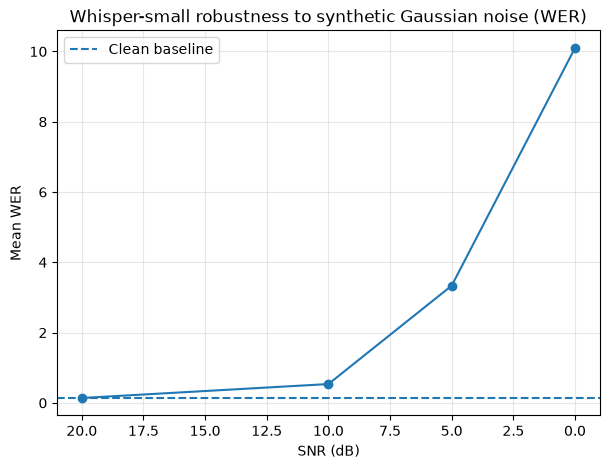

In [122]:
plt.figure(figsize=(7,5))

plt.plot(summary.index,summary['wer'],marker="o")
plt.axhline(clean_wer, linestyle="--",label="Clean baseline")
plt.xlabel("SNR (dB)")
plt.ylabel("Mean WER")
plt.title("Whisper-small robustness to synthetic Gaussian noise (WER)")

plt.legend()
plt.grid(alpha=0.3)
plt.gca().invert_xaxis()

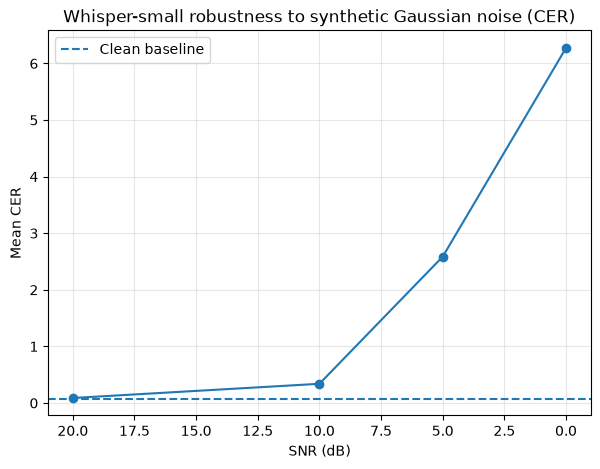

In [123]:
plt.figure(figsize=(7, 5))

plt.plot(summary.index, summary["cer"], marker="o")
plt.axhline(clean_cer, linestyle="--", label="Clean baseline")

plt.xlabel("SNR (dB)")
plt.ylabel("Mean CER")
plt.title("Whisper-small robustness to synthetic Gaussian noise (CER)")
plt.legend()
plt.grid(alpha=0.3)

plt.gca().invert_xaxis()

plt.savefig("../results/cer_vs_snr.png", dpi=300, bbox_inches="tight")
plt.show()

In [120]:
noisy_df[
    ["name", "snr_db", "wer", "cer", "prediction"]
].sort_values("wer", ascending=False).head(5)

,name,snr_db,wer,cer,prediction
11,../data/fr_003.wav,0,30.000000,16.388889,"le modèle de la transporte n'est ni en haut, ..."
7,../data/fr_002.wav,0,17.000000,12.922078,"C'est un peu joli, mais c'est un peu joli, ma..."
18,../data/fr_005.wav,5,13.846154,11.333333,Les réserves ne vont pas s'arrêter de s'arrêt...
15,../data/fr_004.wav,0,1.416667,0.650000,Et vous dressez à vous assurer le système de ...
2,../data/fr_001.wav,5,1.076923,0.610390,"Bonne nuit, un motel m'a eu effectué en un pr..."


In [121]:

Path("../results").mkdir(parents=True, exist_ok=True)


summary_rows = [{
    "condition": "clean",
    "snr_db": None,
    "wer_mean": clean_df["wer"].mean(),
    "wer_median": clean_df["wer"].median(),
    "cer_mean": clean_df["cer"].mean(),
    "cer_median": clean_df["cer"].median(),
}]

for snr_db in [20, 10, 5, 0]:
    subset = noisy_df[noisy_df["snr_db"] == snr_db]

    summary_rows.append({
        "condition": "noisy",
        "snr_db": snr_db,
        "wer_mean": subset["wer"].mean(),
        "wer_median": subset["wer"].median(),
        "cer_mean": subset["cer"].mean(),
        "cer_median": subset["cer"].median(),
    })

summary_df = pd.DataFrame(summary_rows)


worst_failures = (
    noisy_df[
        ["name", "snr_db", "wer", "cer", "prediction"]
    ]
    .sort_values("wer", ascending=False)
    .head(5)
)


summary_df.to_csv(
    "../results/summary_metrics.csv",
    index=False
)

worst_failures.to_csv(
    "../results/worst_failures.csv",
    index=False
)

print("SUMMARY")
display(summary_df.round(3))

print("\nWORST FAILURES")
display(worst_failures)

SUMMARY


,condition,snr_db,wer_mean,wer_median,cer_mean,cer_median
0,clean,NaN,0.129,0.091,0.067,0.039
1,noisy,20.0,0.139,0.091,0.088,0.125
2,noisy,10.0,0.536,0.500,0.339,0.325
3,noisy,5.0,3.337,0.917,2.586,0.538
4,noisy,0.0,10.099,1.417,6.272,0.701



WORST FAILURES


,name,snr_db,wer,cer,prediction
11,../data/fr_003.wav,0,30.000000,16.388889,"le modèle de la transporte n'est ni en haut, ..."
7,../data/fr_002.wav,0,17.000000,12.922078,"C'est un peu joli, mais c'est un peu joli, ma..."
18,../data/fr_005.wav,5,13.846154,11.333333,Les réserves ne vont pas s'arrêter de s'arrêt...
15,../data/fr_004.wav,0,1.416667,0.650000,Et vous dressez à vous assurer le système de ...
2,../data/fr_001.wav,5,1.076923,0.610390,"Bonne nuit, un motel m'a eu effectué en un pr..."


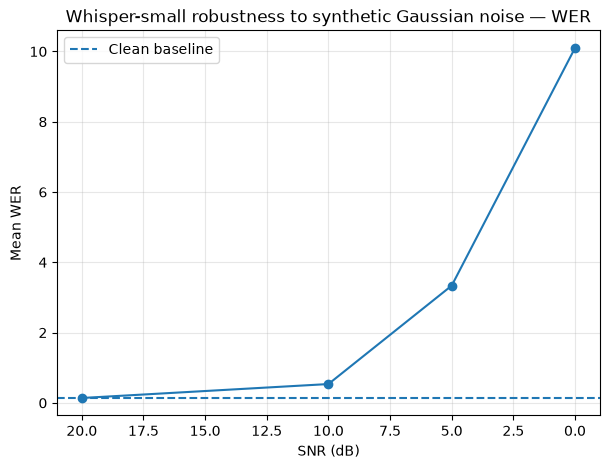

In [124]:

summary = (
    noisy_df
    .groupby("snr_db")[["wer", "cer"]]
    .mean()
    .sort_index()
)

clean_wer = clean_df["wer"].mean()

plt.figure(figsize=(7, 5))
plt.plot(summary.index, summary["wer"], marker="o")
plt.axhline(clean_wer, linestyle="--", label="Clean baseline")

plt.xlabel("SNR (dB)")
plt.ylabel("Mean WER")
plt.title("Whisper-small robustness to synthetic Gaussian noise — WER")
plt.legend()
plt.grid(alpha=0.3)

plt.gca().invert_xaxis()

plt.savefig("../results/wer_vs_snr.png", dpi=300, bbox_inches="tight")
plt.show()